# Gemstone Classification: Standard CNN vs Prototypical Network
### DS402.3 — Neural Networks Assignment

## Cell 1 — Install Dependencies

In [1]:
!pip install torch torchvision matplotlib scikit-learn seaborn tqdm pandas kagglehub --quiet

## Cell 2 — Imports & Reproducibility

In [3]:
import os, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from collections import Counter
import kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Cell 3 — Dataset Path & Verification

In [11]:
import kagglehub
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("fransell/gemstones-images-expanded")

# Check for common subfolders where the actual image data might reside
# Prioritize 'dataset-expanded' as it's indicated by previous runs as a top-level directory
if os.path.isdir(os.path.join(path, 'dataset-expanded')):
    DATASET_ROOT = os.path.join(path, 'dataset-expanded')
elif os.path.isdir(os.path.join(path, 'gemstones')):
    DATASET_ROOT = os.path.join(path, 'gemstones')
elif os.path.isdir(os.path.join(path, 'Gemstones_Dataset')):
    DATASET_ROOT = os.path.join(path, 'Gemstones_Dataset')
else:
    # Fallback to the direct path if no specific subfolder is found
    DATASET_ROOT = path

print("Path to dataset files:", DATASET_ROOT)

# Verify the path and structure (original code from the cell)
assert os.path.exists(DATASET_ROOT), f'Path not found: {DATASET_ROOT}'

all_classes = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print(f'Total classes found : {len(all_classes)}')

# Count images per class
counts = {}
for cls in all_classes:
    cls_path = os.path.join(DATASET_ROOT, cls)
    counts[cls] = len([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

print(f'Min images per class : {min(counts.values())}')
print(f'Max images per class : {max(counts.values())}')
print(f'Avg images per class : {np.mean(list(counts.values())):.1f}')
print(f'Total images         : {sum(counts.values())}')

Using Colab cache for faster access to the 'gemstones-images-expanded' dataset.
Path to dataset files: /kaggle/input/gemstones-images-expanded/dataset-expanded
Total classes found : 88
Min images per class : 50
Max images per class : 50
Avg images per class : 50.0
Total images         : 4400


## Cell 4 — Class Split (60 Base / 28 Novel)

In [12]:
# Shuffle with fixed seed for reproducibility
shuffled = all_classes.copy()
random.shuffle(shuffled)

BASE_CLASSES  = shuffled[:60]   # used to train CNN and meta-train ProtoNet
NOVEL_CLASSES = shuffled[60:]   # held out — only used for few-shot testing

print(f'Base  classes : {len(BASE_CLASSES)}')
print(f'Novel classes : {len(NOVEL_CLASSES)}')
print(f'\nSample base  : {BASE_CLASSES[:5]}')
print(f'Sample novel : {NOVEL_CLASSES[:5]}')

Base  classes : 60
Novel classes : 28

Sample base  : ['Quartz Lemon', 'Rhodochrosite', 'Garnet Red', 'Dumortierite', 'Chalcedony']
Sample novel : ['Aventurine Yellow', 'Onyx Red', 'Morganite', 'Alexandrite', 'Turquoise']


## Cell 5 — Custom Dataset Class

In [13]:
class GemstoneDataset(Dataset):
    """
    Loads images from a root folder for a specified list of classes only.
    Labels are remapped to 0..N-1 for the given class list.
    """
    def __init__(self, root, class_list, transform=None):
        self.transform = transform
        self.classes   = class_list
        self.class_to_idx = {cls: i for i, cls in enumerate(class_list)}
        self.samples = []

        valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
        for cls in class_list:
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(valid_ext):
                    self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

## Cell 6 — Transforms

In [14]:
IMG_SIZE = 64   # smaller size keeps training fast with ~50 images/class

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

## Cell 7 — Build Datasets & DataLoaders for CNN

In [15]:
base_dataset = GemstoneDataset(DATASET_ROOT, BASE_CLASSES, train_transform)
print(f'Base dataset total samples: {len(base_dataset)}')

# Sanity check — must have many samples, not 0 or 60
assert len(base_dataset) > 500, 'Too few samples loaded. Check DATASET_ROOT path.'

# 80/20 train-val split
n_total = len(base_dataset)
n_train = int(0.8 * n_total)
indices = list(range(n_total))
random.shuffle(indices)

train_set = Subset(base_dataset, indices[:n_train])
val_set   = Subset(base_dataset, indices[n_train:])

# Small batch size suits ~50 images/class
train_loader = DataLoader(train_set, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=16, shuffle=False, num_workers=0)

print(f'Train samples : {len(train_set)}')
print(f'Val   samples : {len(val_set)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

# Confirm batch variety
imgs_check, labels_check = next(iter(train_loader))
print(f'\nUnique labels in first batch : {labels_check.unique().numel()} (expect ~{min(16, len(BASE_CLASSES))})')
print(f'Image tensor shape           : {imgs_check.shape}')

Base dataset total samples: 3000
Train samples : 2400
Val   samples : 600
Train batches : 150
Val   batches : 38

Unique labels in first batch : 13 (expect ~16)
Image tensor shape           : torch.Size([16, 3, 64, 64])


## Cell 8 — Visualise Sample Images

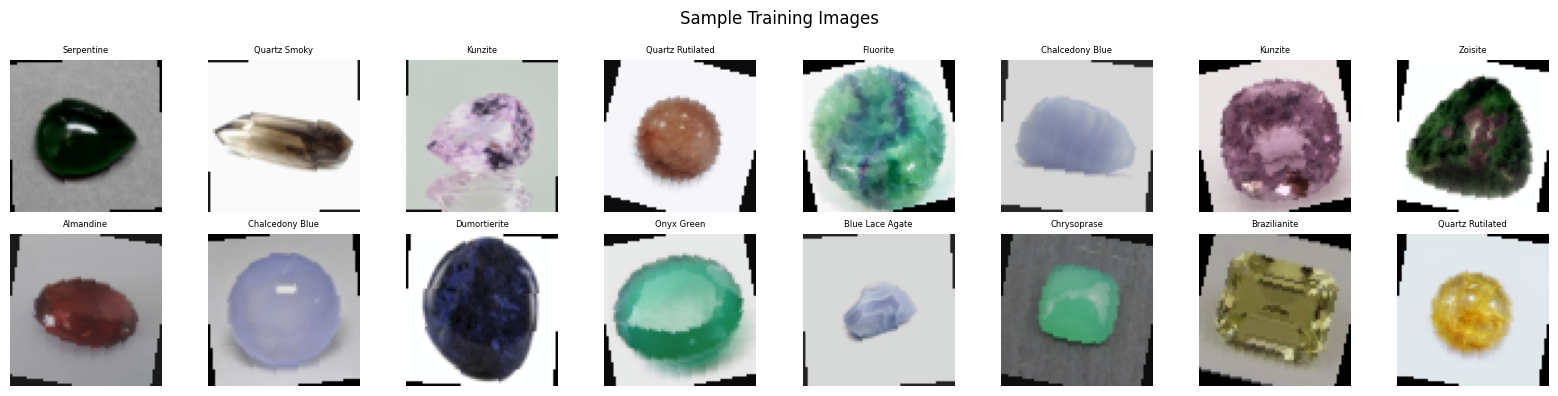

In [16]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(imgs_check[i % len(imgs_check)]))
    ax.set_title(BASE_CLASSES[labels_check[i % len(labels_check)].item()], fontsize=6)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=12)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## Cell 9 — Standard CNN Architecture

In [17]:
class StandardCNN(nn.Module):
    """
    3-block CNN. Kept simple to avoid overfitting on small dataset (~50 imgs/class).
    Dropout added for regularization.
    """
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 -> 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32

            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),   # 32 -> 16

            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4)                           # -> (128, 4, 4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


cnn_model = StandardCNN(num_classes=len(BASE_CLASSES)).to(DEVICE)

# Quick shape check
with torch.no_grad():
    out = cnn_model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f'CNN output shape: {out.shape}  (expect [2, {len(BASE_CLASSES)}])')

CNN output shape: torch.Size([2, 60])  (expect [2, 60])


## Cell 10 — Train Standard CNN with Early Stopping

In [18]:
EPOCHS    = 50   # high ceiling; early stopping will cut this short if needed
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Early stopping config
best_val_loss     = float('inf')
patience          = 7
patience_counter  = 0
min_delta         = 0.001

cnn_train_acc, cnn_val_acc, cnn_val_losses = [], [], []

for epoch in range(1, EPOCHS + 1):

    # ---- Training ----
    cnn_model.train()
    correct, total = 0, 0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = cnn_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    cnn_train_acc.append(correct / total)

    # ---- Validation ----
    cnn_model.eval()
    val_correct, val_total, val_loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = cnn_model(imgs)
            val_loss_sum += criterion(outputs, labels).item() * labels.size(0)
            val_correct  += (outputs.argmax(1) == labels).sum().item()
            val_total    += labels.size(0)

    val_acc  = val_correct / val_total
    val_loss = val_loss_sum / val_total
    cnn_val_acc.append(val_acc)
    cnn_val_losses.append(val_loss)
    scheduler.step()

    print(f'Epoch {epoch:02d} | Train Acc: {cnn_train_acc[-1]:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}')

    # ---- Early stopping check ----
    if val_loss < best_val_loss - min_delta:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(cnn_model.state_dict(), 'cnn_best.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping at epoch {epoch}. Best val loss: {best_val_loss:.4f}')
            break

# Load best weights before evaluation
cnn_model.load_state_dict(torch.load('cnn_best.pth', map_location=DEVICE))
print('\nLoaded best CNN weights.')

Epoch 01 | Train Acc: 0.1158 | Val Acc: 0.2850 | Val Loss: 2.5163


Epoch 02 | Train Acc: 0.2254 | Val Acc: 0.3117 | Val Loss: 2.2818


Epoch 03 | Train Acc: 0.2879 | Val Acc: 0.3933 | Val Loss: 1.9193


Epoch 04 | Train Acc: 0.3254 | Val Acc: 0.4100 | Val Loss: 1.8171


Epoch 05 | Train Acc: 0.3713 | Val Acc: 0.4500 | Val Loss: 1.7032


...

Epoch 34 | Train Acc: 0.6621 | Val Acc: 0.6683 | Val Loss: 1.0286


Epoch 35 | Train Acc: 0.6692 | Val Acc: 0.6583 | Val Loss: 0.9992


Epoch 36 | Train Acc: 0.6925 | Val Acc: 0.6617 | Val Loss: 1.0075


Epoch 37 | Train Acc: 0.6921 | Val Acc: 0.6750 | Val Loss: 0.9998


Epoch 38 | Train Acc: 0.6800 | Val Acc: 0.6683 | Val Loss: 1.0033

Early stopping at epoch 38. Best val loss: 0.9947

Loaded best CNN weights.


## Cell 11 — CNN Training Curves

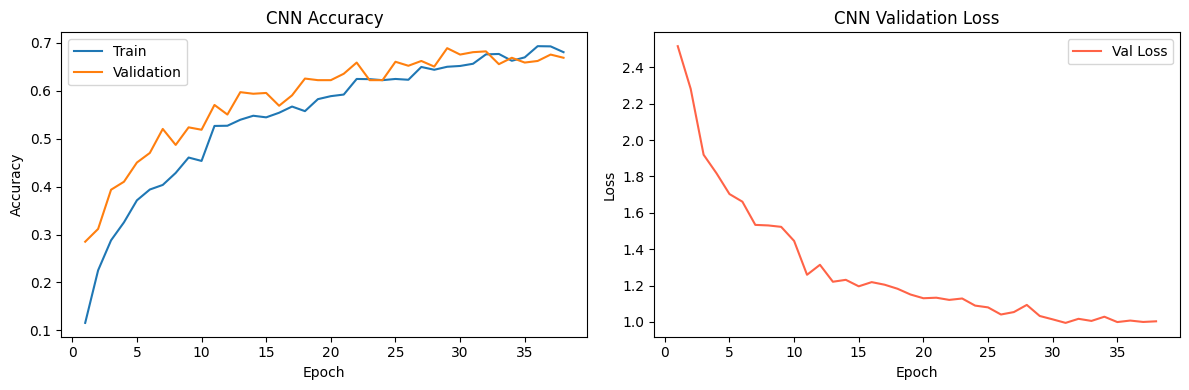

Final Train Acc : 0.6800
Best  Val Acc   : 0.6883


In [19]:
epochs_ran = list(range(1, len(cnn_train_acc) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, cnn_train_acc, label='Train')
axes[0].plot(epochs_ran, cnn_val_acc,   label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN Accuracy'); axes[0].legend()

axes[1].plot(epochs_ran, cnn_val_losses, color='tomato', label='Val Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('CNN Validation Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
plt.show()

print(f'Final Train Acc : {cnn_train_acc[-1]:.4f}')
print(f'Best  Val Acc   : {max(cnn_val_acc):.4f}')

## Cell 12 — CNN Accuracy on Novel Classes (Baseline)

The CNN was never trained on novel classes. This score shows how a standard model fails when classes are unseen — the key motivation for few-shot learning.

In [20]:
# Build novel dataset — labels 0..27 within novel class space
novel_dataset = GemstoneDataset(DATASET_ROOT, NOVEL_CLASSES, eval_transform)
novel_loader  = DataLoader(novel_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f'Novel samples: {len(novel_dataset)}')
assert len(novel_dataset) > 0, 'Novel dataset is empty. Check DATASET_ROOT.'

# CNN outputs logits for 60 base classes.
# On novel (unseen) classes, predictions are random -> near-chance accuracy.
# We compute accuracy treating it as a 60-class problem — novel label ids
# fall outside [0,59] so correct matches will be near 0.
cnn_model.eval()
novel_correct, novel_total = 0, 0

with torch.no_grad():
    for imgs, labels in novel_loader:
        imgs = imgs.to(DEVICE)
        preds = cnn_model(imgs).argmax(1).cpu()
        # labels are 0..27 (novel), preds are 0..59 (base) — intentional mismatch
        novel_correct += (preds == labels).sum().item()
        novel_total   += labels.size(0)

cnn_novel_acc = novel_correct / novel_total
print(f'\nCNN on novel classes: {cnn_novel_acc:.4f}  (expected near 0 — model never saw these classes)')

Novel samples: 1400

CNN on novel classes: 0.0071  (expected near 0 — model never saw these classes)


## Cell 13 — Embedding Network for Prototypical Network

In [21]:
class EmbeddingNet(nn.Module):
    """
    Shared encoder for Prototypical Network.
    Maps each image to a 128-dim embedding vector.
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)   # global average -> (B, 128, 1, 1)
        )

    def forward(self, x):
        return self.encoder(x).squeeze(-1).squeeze(-1)   # (B, 128)


embed_net = EmbeddingNet().to(DEVICE)

with torch.no_grad():
    test_out = embed_net(torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f'Embedding shape: {test_out.shape}  (expect [4, 128])')

Embedding shape: torch.Size([4, 128])  (expect [4, 128])


## Cell 14 — Episode Sampler

In [22]:
def build_class_index(dataset):
    """Pre-build a dict mapping label -> list of dataset indices."""
    idx_map = {}
    for i, (_, label) in enumerate(dataset.samples):
        idx_map.setdefault(label, []).append(i)
    return idx_map


def sample_episode(dataset, class_index, n_way=5, k_shot=5, n_query=5):
    """
    Sample one N-way K-shot episode.
    With ~50 images/class: k_shot=5, n_query=5 leaves room and avoids errors.
    """
    available = [c for c, idxs in class_index.items() if len(idxs) >= k_shot + n_query]
    assert len(available) >= n_way, f'Not enough classes with sufficient images. Have {len(available)}, need {n_way}.'

    episode_classes = random.sample(available, n_way)
    support_imgs, support_labels = [], []
    query_imgs,   query_labels   = [], []

    for new_label, cls in enumerate(episode_classes):
        chosen = random.sample(class_index[cls], k_shot + n_query)
        for i in chosen[:k_shot]:
            img, _ = dataset[i]
            support_imgs.append(img)
            support_labels.append(new_label)
        for i in chosen[k_shot:]:
            img, _ = dataset[i]
            query_imgs.append(img)
            query_labels.append(new_label)

    return (
        torch.stack(support_imgs).to(DEVICE), torch.tensor(support_labels).to(DEVICE),
        torch.stack(query_imgs).to(DEVICE),   torch.tensor(query_labels).to(DEVICE)
    )


# Pre-build class indexes
base_eval_dataset = GemstoneDataset(DATASET_ROOT, BASE_CLASSES,  eval_transform)
base_class_index  = build_class_index(base_eval_dataset)
novel_class_index = build_class_index(novel_dataset)

print(f'Base  classes available for episodes : {len(base_class_index)}')
print(f'Novel classes available for episodes : {len(novel_class_index)}')

Base  classes available for episodes : 60
Novel classes available for episodes : 28


## Cell 15 — Prototypical Loss Function

In [23]:
def prototypical_loss(embed_net, s_imgs, s_labels, q_imgs, q_labels, n_way):
    """
    1. Embed support images; average per class -> prototypes
    2. Embed query images
    3. Classify by nearest prototype (Euclidean distance)
    4. Return cross-entropy loss and episode accuracy
    """
    s_emb = embed_net(s_imgs)   # (n_way * k_shot, D)
    q_emb = embed_net(q_imgs)   # (n_way * n_query, D)

    prototypes = torch.stack([
        s_emb[s_labels == c].mean(0) for c in range(n_way)
    ])                          # (n_way, D)

    dists  = torch.cdist(q_emb, prototypes)   # (n_query_total, n_way)
    logits = -dists

    loss = F.cross_entropy(logits, q_labels)
    acc  = (logits.argmax(1) == q_labels).float().mean().item()
    return loss, acc

## Cell 16 — Meta-Train Prototypical Network with Early Stopping

In [24]:
N_WAY            = 5
K_SHOT           = 5
N_QUERY          = 5
TRAIN_EPISODES   = 600
VAL_EPISODES     = 100   # validation episodes every 100 training episodes
VAL_EVERY        = 100

proto_optimizer  = optim.Adam(embed_net.parameters(), lr=1e-3)
proto_scheduler  = optim.lr_scheduler.StepLR(proto_optimizer, step_size=200, gamma=0.5)

# Early stopping for ProtoNet
best_proto_val   = 0.0
proto_patience   = 3   # in units of validation checkpoints (3 x 100 = 300 episodes)
proto_counter    = 0

proto_train_accs = []
proto_val_accs   = []

embed_net.train()
for ep in range(1, TRAIN_EPISODES + 1):
    s_imgs, s_labels, q_imgs, q_labels = sample_episode(
        base_eval_dataset, base_class_index, N_WAY, K_SHOT, N_QUERY
    )
    proto_optimizer.zero_grad()
    loss, acc = prototypical_loss(embed_net, s_imgs, s_labels, q_imgs, q_labels, N_WAY)
    loss.backward()
    proto_optimizer.step()
    proto_train_accs.append(acc)
    proto_scheduler.step()

    # ---- Periodic validation ----
    if ep % VAL_EVERY == 0:
        embed_net.eval()
        v_accs = []
        with torch.no_grad():
            for _ in range(VAL_EPISODES):
                sv, sl, qv, ql = sample_episode(
                    base_eval_dataset, base_class_index, N_WAY, K_SHOT, N_QUERY
                )
                _, va = prototypical_loss(embed_net, sv, sl, qv, ql, N_WAY)
                v_accs.append(va)
        val_mean = np.mean(v_accs)
        proto_val_accs.append(val_mean)
        train_mean = np.mean(proto_train_accs[-VAL_EVERY:])
        print(f'Episode {ep:04d} | Train Acc (last {VAL_EVERY}): {train_mean:.4f} | Val Acc: {val_mean:.4f}')

        if val_mean > best_proto_val + 0.001:
            best_proto_val = val_mean
            proto_counter  = 0
            torch.save(embed_net.state_dict(), 'embed_best.pth')
        else:
            proto_counter += 1
            if proto_counter >= proto_patience:
                print(f'\nEarly stopping ProtoNet at episode {ep}. Best val acc: {best_proto_val:.4f}')
                break
        embed_net.train()

# Load best weights
embed_net.load_state_dict(torch.load('embed_best.pth', map_location=DEVICE))
print('\nLoaded best embedding net weights.')

Episode 0100 | Train Acc (last 100): 0.7580 | Val Acc: 0.7484
Episode 0200 | Train Acc (last 100): 0.8036 | Val Acc: 0.8060
Episode 0300 | Train Acc (last 100): 0.8352 | Val Acc: 0.8268
Episode 0400 | Train Acc (last 100): 0.8604 | Val Acc: 0.8132
Episode 0500 | Train Acc (last 100): 0.8696 | Val Acc: 0.8420
Episode 0600 | Train Acc (last 100): 0.8660 | Val Acc: 0.8252

Loaded best embedding net weights.


## Cell 17 — ProtoNet Training Progress Plot

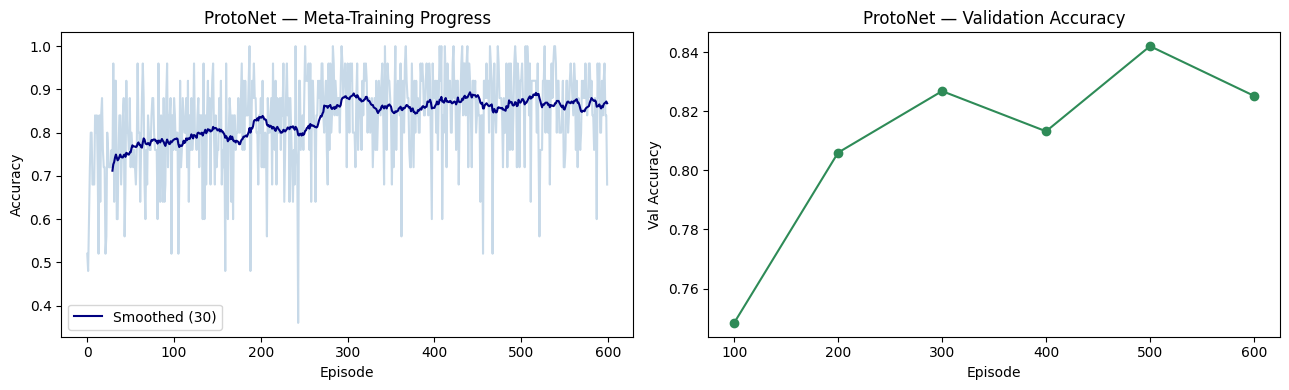

In [25]:
window   = 30
smoothed = np.convolve(proto_train_accs, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(proto_train_accs, alpha=0.3, color='steelblue')
axes[0].plot(range(window-1, len(proto_train_accs)), smoothed, color='navy', label=f'Smoothed ({window})')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('ProtoNet — Meta-Training Progress'); axes[0].legend()

if proto_val_accs:
    axes[1].plot(range(VAL_EVERY, VAL_EVERY*(len(proto_val_accs)+1), VAL_EVERY), proto_val_accs,
                 marker='o', color='seagreen')
    axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Val Accuracy')
    axes[1].set_title('ProtoNet — Validation Accuracy')

plt.tight_layout()
plt.savefig('proto_training_curves.png', dpi=150)
plt.show()

## Cell 18 — Evaluate ProtoNet on Novel Classes (5-shot)

In [26]:
TEST_EPISODES = 200

embed_net.eval()
test_accs = []

with torch.no_grad():
    for _ in range(TEST_EPISODES):
        s_imgs, s_labels, q_imgs, q_labels = sample_episode(
            novel_dataset, novel_class_index, N_WAY, K_SHOT, N_QUERY
        )
        _, acc = prototypical_loss(embed_net, s_imgs, s_labels, q_imgs, q_labels, N_WAY)
        test_accs.append(acc)

proto_mean = np.mean(test_accs)
proto_ci95 = 1.96 * np.std(test_accs) / np.sqrt(TEST_EPISODES)

print(f'Prototypical Network — {N_WAY}-way {K_SHOT}-shot on Novel Classes')
print(f'Mean Accuracy : {proto_mean:.4f}')
print(f'95% CI        : ± {proto_ci95:.4f}')
print(f'Random chance : {1/N_WAY:.4f}')

Prototypical Network — 5-way 5-shot on Novel Classes
Mean Accuracy : 0.8294
95% CI        : ± 0.0132
Random chance : 0.2000


## Cell 19 — Results Summary Table

In [27]:
results = pd.DataFrame({
    'Model': [
        'Standard CNN (base classes, val)',
        'Standard CNN (novel classes — unseen)',
        f'Prototypical Network ({N_WAY}-way {K_SHOT}-shot, novel)'
    ],
    'Accuracy': [
        f'{max(cnn_val_acc):.4f}',
        f'{cnn_novel_acc:.4f}',
        f'{proto_mean:.4f}'
    ],
    '95% CI': ['—', '—', f'± {proto_ci95:.4f}'],
    'Training Data for Novel Classes': [
        'None (never saw novel)',
        'None (never saw novel)',
        f'{K_SHOT} images per class'
    ]
})

print(results.to_string(index=False))
results.to_csv('results_summary.csv', index=False)

                                     Model Accuracy   95% CI Training Data for Novel Classes
          Standard CNN (base classes, val)   0.6883        —          None (never saw novel)
     Standard CNN (novel classes — unseen)   0.0071        —          None (never saw novel)
Prototypical Network (5-way 5-shot, novel)   0.8294 ± 0.0132              5 images per class


## Cell 20 — Bar Chart: CNN vs ProtoNet on Novel Classes

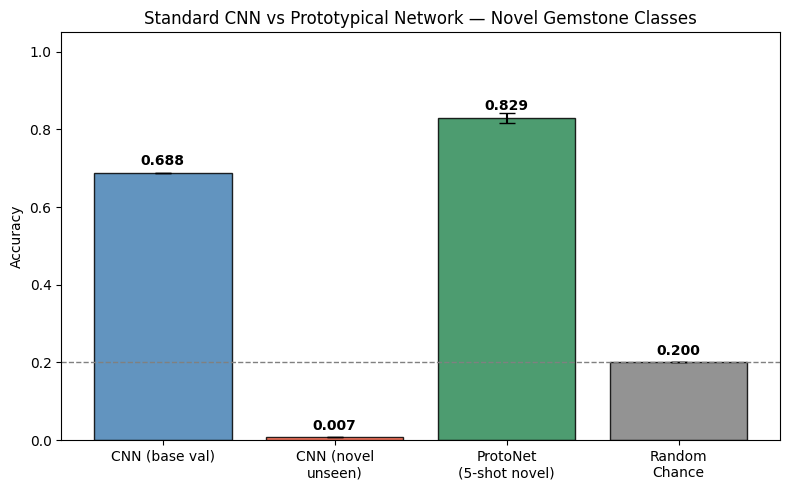

In [28]:
labels  = ['CNN (base val)', 'CNN (novel\nunseen)', f'ProtoNet\n({K_SHOT}-shot novel)', 'Random\nChance']
values  = [max(cnn_val_acc), cnn_novel_acc, proto_mean, 1/N_WAY]
errors  = [0, 0, proto_ci95, 0]
colors  = ['steelblue', 'tomato', 'seagreen', 'gray']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, yerr=errors, capsize=6,
               color=colors, edgecolor='black', alpha=0.85)
plt.ylim(0, 1.05)
plt.axhline(1/N_WAY, linestyle='--', color='gray', linewidth=1, label='Random chance')
plt.ylabel('Accuracy')
plt.title('Standard CNN vs Prototypical Network — Novel Gemstone Classes')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_bar_chart.png', dpi=150)
plt.show()

## Cell 21 — ProtoNet Accuracy Distribution

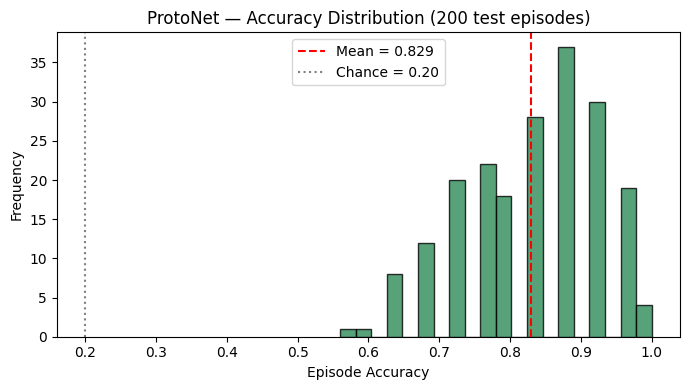

In [29]:
plt.figure(figsize=(7, 4))
plt.hist(test_accs, bins=20, color='seagreen', edgecolor='black', alpha=0.8)
plt.axvline(proto_mean, color='red',  linestyle='--', label=f'Mean = {proto_mean:.3f}')
plt.axvline(1/N_WAY,    color='gray', linestyle=':',  label=f'Chance = {1/N_WAY:.2f}')
plt.xlabel('Episode Accuracy')
plt.ylabel('Frequency')
plt.title(f'ProtoNet — Accuracy Distribution ({TEST_EPISODES} test episodes)')
plt.legend()
plt.tight_layout()
plt.savefig('proto_accuracy_dist.png', dpi=150)
plt.show()

## Cell 22 — t-SNE Embedding Visualisation

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_2125/2540046423.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10', len(TSNE_CLASSES))


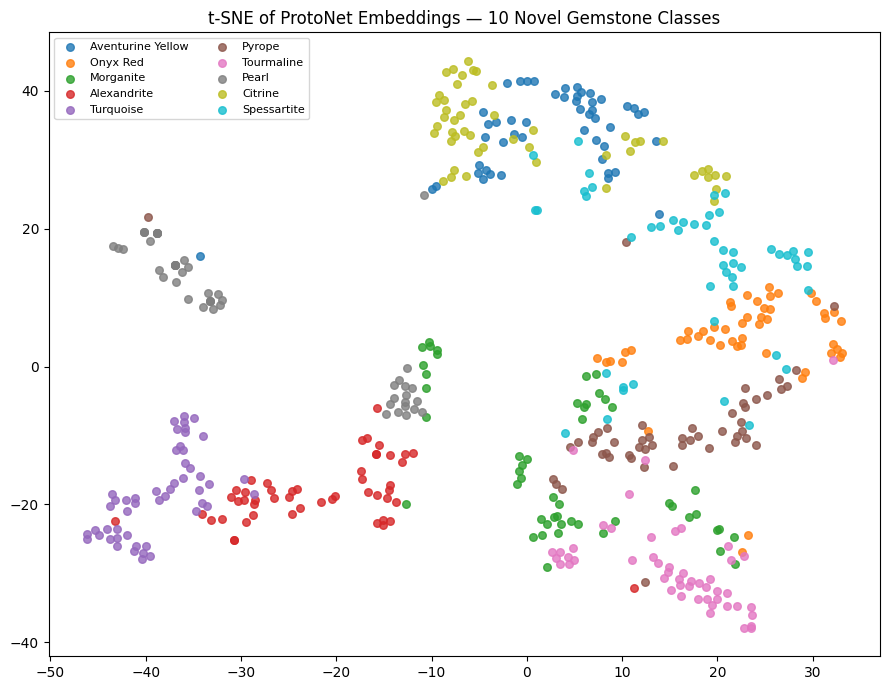

In [30]:
# Use 10 novel classes for cleaner visualisation
TSNE_CLASSES  = NOVEL_CLASSES[:10]
tsne_dataset  = GemstoneDataset(DATASET_ROOT, TSNE_CLASSES, eval_transform)
tsne_loader   = DataLoader(tsne_dataset, batch_size=32, shuffle=False, num_workers=0)

embed_net.eval()
all_embs, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tsne_loader:
        embs = embed_net(imgs.to(DEVICE)).cpu().numpy()
        all_embs.append(embs)
        all_labels.extend(labels.numpy())

all_embs   = np.vstack(all_embs)
all_labels = np.array(all_labels)

tsne_2d = TSNE(n_components=2, random_state=SEED, perplexity=15, n_iter=1000).fit_transform(all_embs)

palette = plt.cm.get_cmap('tab10', len(TSNE_CLASSES))
plt.figure(figsize=(9, 7))
for i, cls in enumerate(TSNE_CLASSES):
    mask = all_labels == i
    plt.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1],
                s=30, color=palette(i), label=cls, alpha=0.8)
plt.legend(fontsize=8, loc='best', ncol=2)
plt.title('t-SNE of ProtoNet Embeddings — 10 Novel Gemstone Classes')
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=150)
plt.show()

## Cell 23 — Save All Metrics

In [31]:
metrics = {
    'experiment_config': {
        'img_size': IMG_SIZE, 'n_way': N_WAY, 'k_shot': K_SHOT,
        'n_query': N_QUERY, 'test_episodes': TEST_EPISODES
    },
    'cnn': {
        'best_val_accuracy'    : max(cnn_val_acc),
        'final_train_accuracy' : cnn_train_acc[-1],
        'novel_accuracy'       : cnn_novel_acc,
        'train_acc_per_epoch'  : cnn_train_acc,
        'val_acc_per_epoch'    : cnn_val_acc,
        'val_loss_per_epoch'   : cnn_val_losses,
    },
    'prototypical_network': {
        'mean_test_accuracy'   : proto_mean,
        'ci_95'                : proto_ci95,
        'random_chance'        : 1 / N_WAY,
    }
}

with open('experiment_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved: experiment_metrics.json')
print('Saved: results_summary.csv')
print('Saved figures: cnn_training_curves.png, comparison_bar_chart.png,')
print('               proto_training_curves.png, proto_accuracy_dist.png, tsne_embeddings.png')

Saved: experiment_metrics.json
Saved: results_summary.csv
Saved figures: cnn_training_curves.png, comparison_bar_chart.png,
               proto_training_curves.png, proto_accuracy_dist.png, tsne_embeddings.png
